# Bipartite transitivity filter

This notebook applies the filtering procedure to an empirical bipartite network using the output produced by the C++ clustering/rewiring code.

The workflow is:

1. Load the clustering coefficients of the original network.
2. Load the clustering coefficients measured in the degree-preserving rewired networks.
3. Build the null distribution of clustering for every degree.
4. Inspect the null distribution for one selected degree.
5. Plot the observed clustering profile together with two selected null percentiles.
6. Classify second-layer nodes according to the degree-dependent null threshold and save the filtered bipartite network.

Only the **configuration cell below** should normally need to be edited.


In [13]:
# ============================================================
# USER SETTINGS — edit this cell only
# ============================================================

# Files produced by / used with the C++ code
ORIGINAL_CLUSTERING_FILE = "clustering_sample0.dat"
REWIRED_CLUSTERING_FILE  = "clustering_rewiring_sample0.dat"
EDGE_LIST_FILE           = "sample_p0.dat"

# Degree whose null clustering distribution you want to inspect
HISTOGRAM_DEGREE = 5

# Two null percentiles to show in the clustering-vs-degree profile.
# Example: 95 corresponds to the one-sided upper 5% tail of the null distribution.
PROFILE_PERCENTILES = [95, 99]

# Percentiles for which filtered networks will be written.
# Change this list if you only want selected thresholds.
FILTER_PERCENTILES = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9, 100]

# In the bipartite edge list, the C++ code computes clustering for the second layer.
# Therefore the second column (index 1) is filtered by default.
TARGET_EDGE_COLUMN = 1

# Folder where all generated files will be saved
OUTPUT_DIR = "filter_results"

# Number of bins in the null-distribution histogram
HISTOGRAM_BINS = 20


## 1. Load the data

Expected inputs:

- `ORIGINAL_CLUSTERING_FILE`: clustering measured in the original network. The usual format is  
  `node_id  degree  clustering`.
- `REWIRED_CLUSTERING_FILE`: clustering measured across the degree-preserving randomized networks.
  The loader accepts the formats used by the different versions of the C++ program:
  - `degree  clustering`
  - `node_id  degree  clustering`
  - `node_id  degree  original_clustering  rewired_clustering`
  - `node_id  degree  original_clustering  rewired_clustering  ratio`
- `EDGE_LIST_FILE`: the original bipartite edge list with two columns.

Columns may be separated by spaces or tabs and the files should not contain headers.


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde
except ImportError:
    gaussian_kde = None

if len(PROFILE_PERCENTILES) != 2:
    raise ValueError("PROFILE_PERCENTILES must contain exactly two values.")

for p in PROFILE_PERCENTILES + FILTER_PERCENTILES:
    if not (0 <= p <= 100):
        raise ValueError(f"Percentile {p} is outside the valid range [0, 100].")

if TARGET_EDGE_COLUMN not in (0, 1):
    raise ValueError("TARGET_EDGE_COLUMN must be 0 or 1.")

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)


def _read_numeric_table(path):
    """Read a whitespace-separated file and coerce all columns to numeric."""
    df = pd.read_csv(path, sep=r"\s+", header=None, comment="#")
    if df.empty:
        raise ValueError(f"{path} is empty.")
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(how="any").reset_index(drop=True)
    if df.empty:
        raise ValueError(f"{path} contains no valid numeric rows.")
    return df


def load_original_clustering(path):
    raw = _read_numeric_table(path)
    if raw.shape[1] < 3:
        raise ValueError(
            f"{path} must contain at least 3 columns: node_id, degree, clustering."
        )
    out = raw.iloc[:, :3].copy()
    out.columns = ["node", "degree", "clustering"]
    out["node"] = out["node"].astype(int)
    out["degree"] = out["degree"].astype(int)
    return out


def load_rewired_clustering(path):
    """
    Normalize the different rewiring-output formats to:
        node (optional), degree, clustering
    """
    raw = _read_numeric_table(path)
    ncols = raw.shape[1]

    if ncols == 2:
        out = raw.iloc[:, [0, 1]].copy()
        out.columns = ["degree", "clustering"]
    elif ncols == 3:
        out = raw.iloc[:, [0, 1, 2]].copy()
        out.columns = ["node", "degree", "clustering"]
    elif ncols >= 4:
        # Current C++ format:
        # node, degree, original clustering, rewired clustering [, ratio]
        out = raw.iloc[:, [0, 1, 3]].copy()
        out.columns = ["node", "degree", "clustering"]
    else:
        raise ValueError(f"Unsupported rewiring format in {path}.")

    out["degree"] = out["degree"].astype(int)
    if "node" in out.columns:
        out["node"] = out["node"].astype(int)
    return out


def load_edge_list(path):
    raw = _read_numeric_table(path)
    if raw.shape[1] != 2:
        raise ValueError(f"{path} must contain exactly two columns.")
    raw.columns = ["layer_1", "layer_2"]
    raw["layer_1"] = raw["layer_1"].astype(int)
    raw["layer_2"] = raw["layer_2"].astype(int)
    return raw


df_sample = load_original_clustering(ORIGINAL_CLUSTERING_FILE)
df_rewiring = load_rewired_clustering(REWIRED_CLUSTERING_FILE)
edge_list = load_edge_list(EDGE_LIST_FILE)

print(f"Original clustering: {len(df_sample):,} nodes")
print(f"Rewiring sample:     {len(df_rewiring):,} node-realisation measurements")
print(f"Original edge list:  {len(edge_list):,} edges")
print(f"Degrees in original network: {df_sample['degree'].min()}–{df_sample['degree'].max()}")


Original clustering: 995 nodes
Rewiring sample:     199,995 node-realisation measurements
Original edge list:  16,431 edges
Degrees in original network: 2–393


## 2. Degree-dependent null distributions

For each degree \(k\), the rewired networks provide a sample of the clustering coefficient under the degree-preserving null model. The selected percentiles of these distributions define the filtering thresholds.


In [15]:
# Percentiles required anywhere in the notebook
ALL_PERCENTILES = sorted(set(PROFILE_PERCENTILES + FILTER_PERCENTILES))

degrees_in_null = np.sort(df_rewiring["degree"].unique())
percentile_rows = []

for degree in degrees_in_null:
    values = df_rewiring.loc[df_rewiring["degree"] == degree, "clustering"].to_numpy()
    row = {"degree": int(degree), "n_null": len(values)}
    for p in ALL_PERCENTILES:
        row[f"p{p:g}"] = np.percentile(values, p)
    percentile_rows.append(row)

df_percentiles = pd.DataFrame(percentile_rows).sort_values("degree").reset_index(drop=True)
df_percentiles.to_csv(
    output_dir / "null_percentiles_by_degree.tsv",
    sep="\t",
    index=False
)

display(df_percentiles.head(10))


,degree,n_null,p50,p55,p60,p65,p70,p75,p80,p85,p90,p95,p99,p99.9,p100
0,2,1809,0.062500,0.071429,0.076923,0.083333,0.090909,0.111111,0.117647,0.133333,0.153846,0.187500,0.250000,0.357143,0.375000
1,3,6633,0.059259,0.064815,0.070370,0.076605,0.083333,0.091282,0.100000,0.111111,0.125000,0.148352,0.195613,0.263868,0.328431
2,4,6834,0.061688,0.065599,0.070370,0.075092,0.080150,0.086037,0.092424,0.100000,0.111111,0.128291,0.163829,0.207215,0.257143
3,5,8844,0.061833,0.065373,0.068909,0.072816,0.076594,0.081667,0.087190,0.094345,0.103453,0.116587,0.148018,0.185435,0.213476
4,6,11256,0.062222,0.065418,0.068291,0.071946,0.075827,0.080017,0.084909,0.090588,0.097662,0.110112,0.135069,0.166008,0.209482
5,7,14673,0.062843,0.065673,0.068763,0.071868,0.075220,0.078815,0.083130,0.088073,0.095084,0.106014,0.126844,0.148553,0.175221
6,8,12864,0.063255,0.065802,0.068532,0.071244,0.074354,0.077811,0.081408,0.086022,0.092047,0.101576,0.121191,0.143601,0.167348
7,9,13266,0.063368,0.065767,0.068125,0.070684,0.073377,0.076591,0.080241,0.084247,0.089768,0.098609,0.115604,0.134187,0.161461
8,10,11256,0.063392,0.065630,0.067872,0.070380,0.072993,0.075713,0.079014,0.083064,0.088202,0.096244,0.114271,0.134426,0.151480
9,11,12261,0.063825,0.065895,0.068072,0.070484,0.072835,0.075622,0.078649,0.082559,0.087859,0.095408,0.110404,0.128201,0.141792


## 3. Null clustering distribution for one degree

This reproduces the histogram-style diagnostic used in the synthetic-network notebook, but without requiring signal/noise class labels. The histogram and optional KDE show the rewired null distribution. Marks at \(y=0\) show the clustering values of nodes of the selected degree in the original network. The two vertical lines are the percentiles selected in the configuration cell.


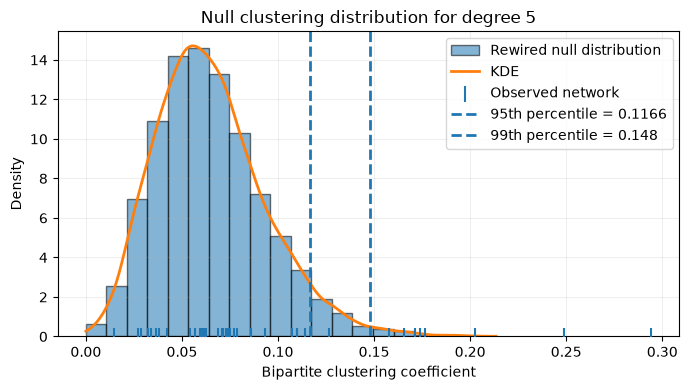

In [16]:
degree = int(HISTOGRAM_DEGREE)

null_values = df_rewiring.loc[
    df_rewiring["degree"] == degree, "clustering"
].dropna().to_numpy()

observed_values = df_sample.loc[
    df_sample["degree"] == degree, "clustering"
].dropna().to_numpy()

if len(null_values) == 0:
    available = ", ".join(map(str, np.sort(df_rewiring["degree"].unique())))
    raise ValueError(
        f"No rewiring values were found for degree {degree}. "
        f"Available degrees are: {available}"
    )

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    null_values,
    bins=HISTOGRAM_BINS,
    density=True,
    alpha=0.55,
    edgecolor="black",
    label="Rewired null distribution"
)

# KDE, when possible
if gaussian_kde is not None and len(null_values) > 1 and np.var(null_values) > 0:
    kde = gaussian_kde(null_values)
    xmin, xmax = null_values.min(), null_values.max()
    if xmax > xmin:
        x = np.linspace(xmin, xmax, 300)
        ax.plot(x, kde(x), linewidth=2, label="KDE")

# Observed nodes of the same degree
if len(observed_values) > 0:
    ax.scatter(
        observed_values,
        np.zeros_like(observed_values),
        marker="|",
        s=140,
        linewidths=1.5,
        label="Observed network",
        zorder=5
    )

for p in PROFILE_PERCENTILES:
    threshold = np.percentile(null_values, p)
    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"{p:g}th percentile = {threshold:.4g}"
    )

ax.set_title(f"Null clustering distribution for degree {degree}")
ax.set_xlabel("Bipartite clustering coefficient")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Clustering profile and two null thresholds

The points show the clustering coefficient of each node in the analyzed bipartite layer. The two curves are the degree-dependent null percentiles selected by `PROFILE_PERCENTILES`.


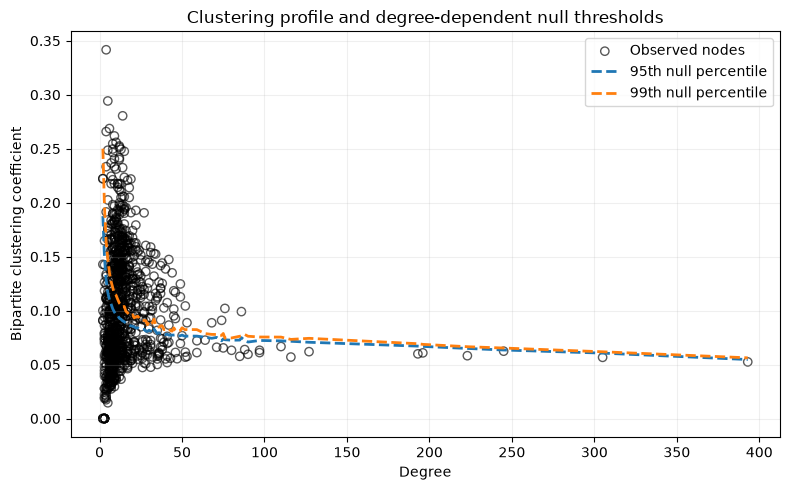

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_sample["degree"],
    df_sample["clustering"],
    facecolors="none",
    edgecolors="black",
    alpha=0.65,
    label="Observed nodes"
)

for p in PROFILE_PERCENTILES:
    column = f"p{p:g}"
    ax.plot(
        df_percentiles["degree"],
        df_percentiles[column],
        linestyle="--",
        linewidth=2,
        label=f"{p:g}th null percentile"
    )

ax.set_xlabel("Degree")
ax.set_ylabel("Bipartite clustering coefficient")
ax.set_title("Clustering profile and degree-dependent null thresholds")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 5. Filter the network

For a percentile threshold \(q\), a node is classified as **compatible with the degree-preserving null model** when

\[
C_3(i) \leq C_{3,q}^{\mathrm{null}}(k_i),
\]

and it is retained in the geometric backbone when its clustering is above that threshold.

For every percentile in `FILTER_PERCENTILES`, the notebook writes:

- `noise_nodes_pXX.dat`: second-layer node IDs classified as null/noise;
- `backbone_nodes_pXX.dat`: second-layer node IDs retained by the filter;
- `noise_network_pXX.dat`: edges incident to null/noise nodes;
- `filtered_network_pXX.dat`: the filtered bipartite network;
- `filter_summary.tsv`: a compact summary of the results.

If a degree is absent from the null sample, the corresponding node is left **unclassified** and is retained rather than silently discarded.


In [18]:
target_col = "layer_1" if TARGET_EDGE_COLUMN == 0 else "layer_2"

# Fast degree -> threshold lookup for every requested percentile
threshold_maps = {
    p: dict(zip(df_percentiles["degree"], df_percentiles[f"p{p:g}"]))
    for p in FILTER_PERCENTILES
}

summary_rows = []
classification_table = df_sample[["node", "degree", "clustering"]].copy()

for p in FILTER_PERCENTILES:
    thresholds = threshold_maps[p]
    threshold_for_node = df_sample["degree"].map(thresholds)

    classified = threshold_for_node.notna()
    is_noise = classified & (df_sample["clustering"] <= threshold_for_node)
    is_backbone = classified & (df_sample["clustering"] > threshold_for_node)
    is_unclassified = ~classified

    # Keep unclassified nodes rather than removing them without a null benchmark
    retained = is_backbone | is_unclassified

    classification_table[f"threshold_p{p:g}"] = threshold_for_node
    classification_table[f"noise_p{p:g}"] = is_noise
    classification_table[f"retained_p{p:g}"] = retained

    noise_nodes = set(df_sample.loc[is_noise, "node"].astype(int))
    backbone_nodes = set(df_sample.loc[retained, "node"].astype(int))

    filtered_edges = edge_list[edge_list[target_col].isin(backbone_nodes)].copy()
    noise_edges = edge_list[edge_list[target_col].isin(noise_nodes)].copy()

    tag = f"{p:g}".replace(".", "p")

    pd.Series(sorted(noise_nodes)).to_csv(
        output_dir / f"noise_nodes_p{tag}.dat",
        sep="\t", index=False, header=False
    )
    pd.Series(sorted(backbone_nodes)).to_csv(
        output_dir / f"backbone_nodes_p{tag}.dat",
        sep="\t", index=False, header=False
    )
    noise_edges.to_csv(
        output_dir / f"noise_network_p{tag}.dat",
        sep="\t", index=False, header=False
    )
    filtered_edges.to_csv(
        output_dir / f"filtered_network_p{tag}.dat",
        sep="\t", index=False, header=False
    )

    summary_rows.append({
        "percentile": p,
        "nodes_total": len(df_sample),
        "nodes_noise": int(is_noise.sum()),
        "nodes_retained": int(retained.sum()),
        "nodes_unclassified": int(is_unclassified.sum()),
        "edges_original": len(edge_list),
        "edges_filtered": len(filtered_edges),
        "edges_noise": len(noise_edges),
    })

classification_table.to_csv(
    output_dir / "node_classification.tsv",
    sep="\t",
    index=False
)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(
    output_dir / "filter_summary.tsv",
    sep="\t",
    index=False
)

display(df_summary)
print(f"\nAll output files were written to: {output_dir.resolve()}")


,percentile,nodes_total,nodes_noise,nodes_retained,nodes_unclassified,edges_original,edges_filtered,edges_noise
0,50.0,995,252,743,0,16431,11788,4642
1,55.0,995,273,722,0,16431,11539,4891
2,60.0,995,301,694,0,16431,11160,5270
3,65.0,995,323,672,0,16431,10468,5962
4,70.0,995,346,649,0,16431,10252,6178
5,75.0,995,370,625,0,16431,9978,6452
6,80.0,995,399,596,0,16431,9482,6948
7,85.0,995,420,575,0,16431,9230,7200
8,90.0,995,451,544,0,16431,8568,7862
9,95.0,995,494,501,0,16431,8106,8324



All output files were written to: C:\Users\lucia\UB2025\features\0 test gitHub\prueba\filter_results


## Interpretation

The rewired networks preserve the bipartite degree sequence and provide the degree-conditioned null distribution of \(C_3\). A node whose observed clustering lies above a chosen upper percentile has more local bipartite transitivity than expected from degree constraints alone and is retained in the filtered backbone.

The choice of percentile controls the strictness of the filter. For example, the 95th null percentile corresponds to retaining nodes in the upper 5% tail of the degree-conditioned null distribution.
